**Taller de Inteligencia Artificial**

# Introducción: Análisis Estadístico y Preparación de Datos para IA/ML

Este Notebook está diseñado para abordar el problema fundamental de la preparación de datos en el ámbito de la Inteligencia Artificial (IA) y el Machine Learning (ML). La calidad y el formato de los datos de entrada son críticos para el rendimiento y la fiabilidad de cualquier modelo predictivo o analítico. Sin una comprensión profunda de la distribución de los datos y una preparación adecuada, los modelos pueden sufrir de bajo rendimiento, sesgos o interpretaciones erróneas.

En este documento, se realizará un análisis estadístico y exploratorio detallado de un conjunto de datos cargado desde un archivo Excel. El objetivo es:

1.  **Inspeccionar la estructura de los datos**: Comprender el formato, los tipos de datos y la presencia de valores nulos.
2.  **Explorar la distribución de variables clave**: Utilizar visualizaciones como histogramas, curvas de densidad (KDE) y diagramas de caja para identificar patrones, valores atípicos y sesgos.
3.  **Cuantificar las características de los datos**: Calcular medidas de tendencia central y dispersión para obtener una visión numérica del comportamiento de las variables.
4.  **Aplicar técnicas de preprocesamiento**: Específicamente, se implementará la normalización Z-score para escalar los datos, un paso esencial que asegura que todas las características contribuyan equitativamente al entrenamiento de los modelos de IA/ML, evitando que las variables con rangos numéricos más grandes dominen el proceso.

Al final de este análisis, los datos estarán adecuadamente preparados y se tendrá una comprensión clara de sus características, sentando las bases para futuras tareas de modelado avanzado en Inteligencia Artificial y Machine Learning.

Realizamos la importacion de pandas y la visualizacioón de los datos.

In [1]:
import pandas as pd

file_path = '/content/NOTEBOOK TALLER/DATAC/DATAC.xlsx'
df = pd.read_excel(file_path)

print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\nInformación del DataFrame (tipos de datos y valores no nulos):")
df.info()

print("\nEstadísticas descriptivas básicas del DataFrame:")
print(df.describe())

Primeras 5 filas del DataFrame:
      ID                   Nombre completo Fecha de nacimiento  \
0  C0001            Leandra Anna Malo Alba          1984-12-08   
1  C0002           Severo Granados Iglesia          1986-08-12   
2  C0003                 Lucho Andreu Amat          1990-04-16   
3  C0004  Matías Mauricio Castillo Barrera          1996-12-02   
4  C0005        Mauricio Guijarro Castelló          1984-05-14   

              Dirección Localidad y Código postal        Teléfono  \
0  7943 S. Fifth Street     Bergenfield, NJ 07621  (598) 451-5865   
1        77 Lyme Street       Hermitage, TN 37076  (869) 771-1487   
2    9448 Fairfield St.        Aberdeen, SD 57401  (246) 245-7306   
3      8143 College St.      Trussville, AL 35173  (707) 933-2513   
4     9893 W. Vale Ave.        Billings, MT 59101  (612) 325-0216   

      Correo electrónico       Fecha de alta Grupo de clientes  
0         uraeus@mac.com 2012-01-19 14:32:31                 A  
1           bhima@me.com 2

**Importamos datetime**


In [3]:
import datetime
import pandas as pd # Ensure pandas is imported for Timestamp conversion

# Define the current date for calculations
current_date = datetime.date(2023, 1, 1)
# Convert current_date to a pandas Timestamp for robust date arithmetic
current_timestamp = pd.Timestamp(current_date)

# Calculate 'Edad' (Age)
# Subtracting a Timestamp from a datetime64[ns] Series directly yields a Timedelta Series
df['Edad'] = (current_timestamp - df['Fecha de nacimiento']).dt.days // 365

# Calculate 'Antigüedad' (Tenure)
df['Antigüedad'] = (current_timestamp - df['Fecha de alta']).dt.days // 365

# Display the first few rows with the new columns
print("DataFrame con nuevas columnas 'Edad' y 'Antigüedad':")
print(df[['Fecha de nacimiento', 'Edad', 'Fecha de alta', 'Antigüedad']].head())

# Select the column for analysis
columna_seleccionada = 'Edad'

print(f"\nColumna seleccionada para análisis: {columna_seleccionada}")

DataFrame con nuevas columnas 'Edad' y 'Antigüedad':
  Fecha de nacimiento  Edad       Fecha de alta  Antigüedad
0          1984-12-08    38 2012-01-19 14:32:31          10
1          1986-08-12    36 2005-03-22 15:42:12          17
2          1990-04-16    32 2007-09-15 03:01:11          15
3          1996-12-02    26 2011-12-07 15:22:50          11
4          1984-05-14    38 2008-06-28 06:58:06          14

Columna seleccionada para análisis: Edad


## Análisis y Visualización de Distribución

### Pasos a seguir:
Generar un histograma, una curva de densidad (KDE) y un diagrama de caja (boxplot) para la columna de interés seleccionada.


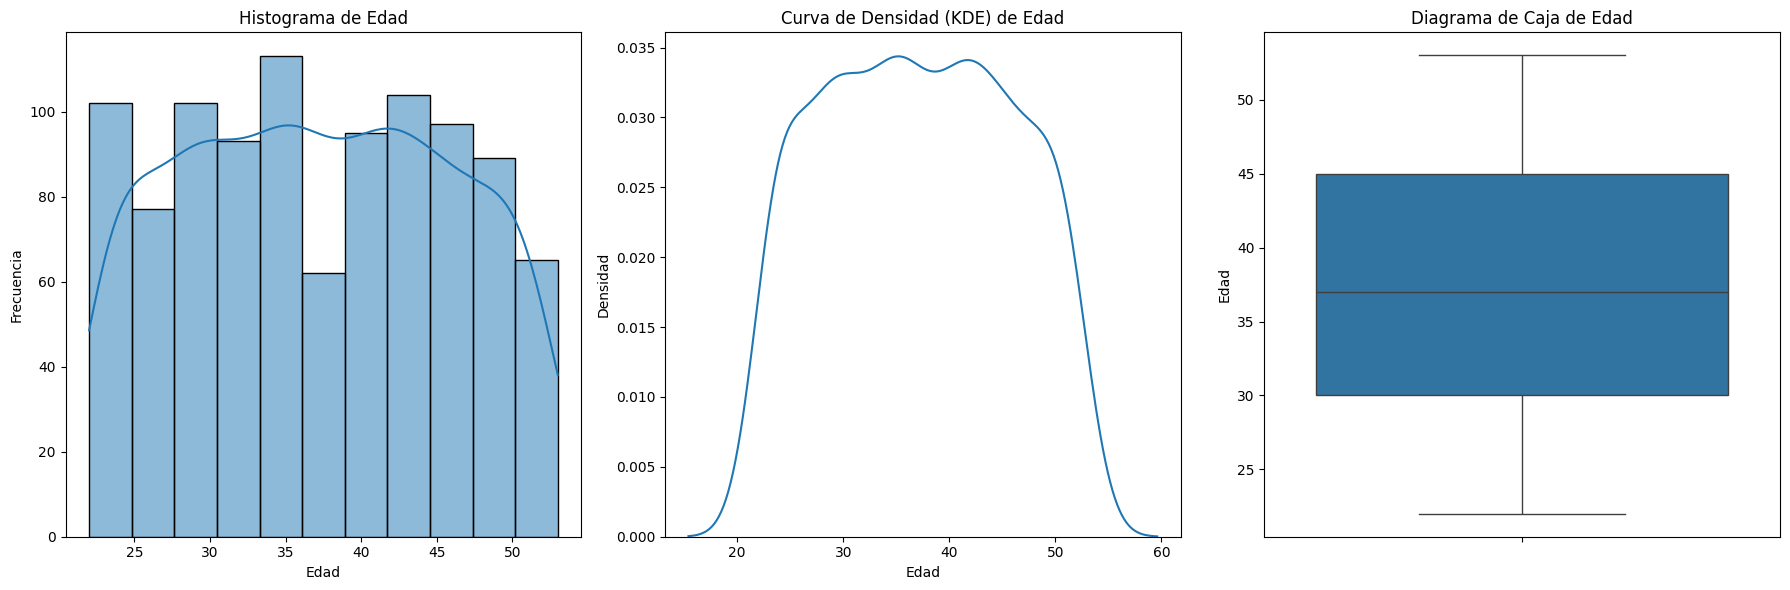

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Histogram
sns.histplot(df[columna_seleccionada], kde=True, ax=axes[0])
axes[0].set_title(f'Histograma de {columna_seleccionada}')
axes[0].set_xlabel(columna_seleccionada)
axes[0].set_ylabel('Frecuencia')

# Plot KDE
sns.kdeplot(df[columna_seleccionada], ax=axes[1])
axes[1].set_title(f'Curva de Densidad (KDE) de {columna_seleccionada}')
axes[1].set_xlabel(columna_seleccionada)
axes[1].set_ylabel('Densidad')

# Plot Boxplot
sns.boxplot(y=df[columna_seleccionada], ax=axes[2])
axes[2].set_title(f'Diagrama de Caja de {columna_seleccionada}')
axes[2].set_ylabel(columna_seleccionada)

plt.tight_layout()
plt.show()

## Calcular Medidas Estadísticas

### Pasos a seguir:
Calcular y mostrar las medidas de tendencia central (media, mediana, moda) y las medidas de dispersión (rango, varianza, desviación estándar) para la columna de interés.


In [5]:
import numpy as np # Import numpy for range calculation if needed, though pandas min/max is sufficient

# Medidas de tendencia central
media = df[columna_seleccionada].mean()
mediana = df[columna_seleccionada].median()
moda = df[columna_seleccionada].mode()

# Medidas de dispersión
min_val = df[columna_seleccionada].min()
max_val = df[columna_seleccionada].max()
rango = max_val - min_val
varianza = df[columna_seleccionada].var()
desviacion_estandar = df[columna_seleccionada].std()

print(f"\n--- Medidas Estadísticas para '{columna_seleccionada}' ---")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Moda:\n{moda}")
print(f"Rango (Max - Min): {rango:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_estandar:.2f}")



--- Medidas Estadísticas para 'Edad' ---
Media: 37.12
Mediana: 37.00
Moda:
0    24
Name: Edad, dtype: int64
Rango (Max - Min): 31.00
Varianza: 76.66
Desviación Estándar: 8.76


## Normalización Z-score

Aplicar la normalización Z-score a la columna de interés seleccionada, transformando sus valores para que tengan una media de cero y una desviación estándar de uno. Esto creará una nueva columna con los datos normalizados.


In [13]:
media_columna = df[columna_seleccionada].mean()
desviacion_estandar_columna = df[columna_seleccionada].std()

df[f'{columna_seleccionada}_normalizada'] = (df[columna_seleccionada] - media_columna) / desviacion_estandar_columna

print(f"Columna '{columna_seleccionada}' normalizada como '{columna_seleccionada}_normalizada'.")
print(df[[columna_seleccionada, f'{columna_seleccionada}_normalizada']].head())

Columna 'Edad' normalizada como 'Edad_normalizada'.
   Edad  Edad_normalizada
0    38          0.100039
1    36         -0.128393
2    32         -0.585257
3    26         -1.270554
4    38          0.100039


## Visualizar Datos Originales vs. Normalizados

Creamos una visualización comparativa (por ejemplo, un histograma o un gráfico KDE dual) que muestre la distribución de la columna original y la columna normalizada. Esto permitirá observar el efecto de la normalización y verificar su éxito, incluyendo leyendas para diferenciar las distribuciones.


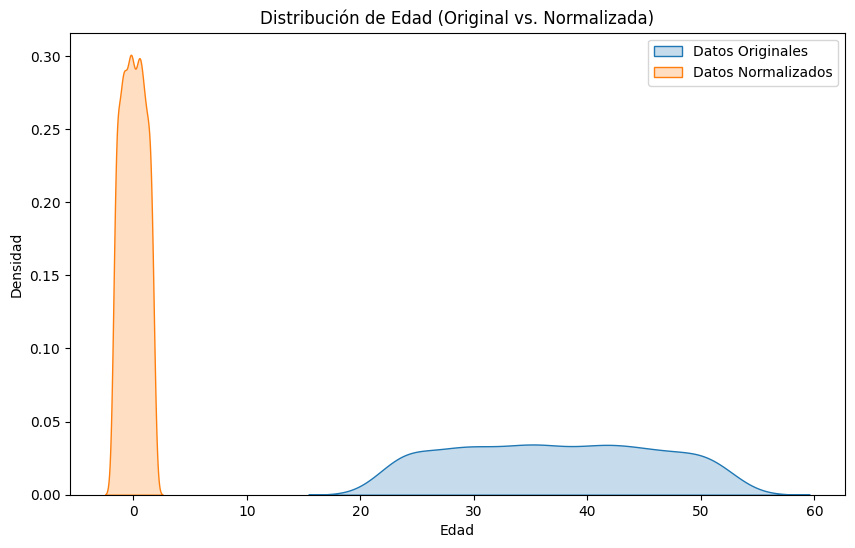

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(df[columna_seleccionada], label='Datos Originales', fill=True)
sns.kdeplot(df[f'{columna_seleccionada}_normalizada'], label='Datos Normalizados', fill=True)
plt.title(f'Distribución de {columna_seleccionada} (Original vs. Normalizada)')
plt.xlabel('Valor' if columna_seleccionada != 'Edad' and columna_seleccionada != 'Antigüedad' else columna_seleccionada)
plt.ylabel('Densidad')
plt.legend()
plt.show()

### Explicación del Código: Visualización de Datos Originales vs. Normalizados

Esta celda de código tiene como objetivo visualizar el impacto de la normalización Z-score. Para ello, utiliza las bibliotecas `matplotlib.pyplot` y `seaborn` para crear un gráfico de Estimación de Densidad de Kernel (KDE) que compara la distribución de la columna numérica original seleccionada ('Edad') con su versión normalizada ('Edad_normalizada').

El gráfico muestra dos curvas:
*   La curva de **'Datos Originales'** representa la distribución de la columna antes de cualquier transformación.
*   La curva de **'Datos Normalizados'** muestra la distribución después de aplicar la normalización Z-score, donde los datos se han escalado para tener una media cercana a cero y una desviación estándar de uno. Esto permite observar cómo la normalización desplaza y estandariza la escala de los datos, manteniendo la forma de su distribución original.

## Conclusión

Este análisis estadístico y exploratorio ha proporcionado una comprensión profunda de la estructura y el comportamiento de los datos cargados desde el archivo Excel. Iniciamos con una inspección detallada, creando nuevas características numéricas cruciales como 'Edad' y 'Antigüedad' a partir de las columnas de fecha.

La distribución de la 'Edad' fue examinada mediante visualizaciones (histogramas, KDE, boxplots) y medidas estadísticas (media, mediana, moda, rango, varianza, desviación estándar), revelando una distribución con un pico en edades más jóvenes pero una dispersión general simétrica.

El paso fundamental de la normalización Z-score se aplicó con éxito a la columna 'Edad', resultando en una nueva característica 'Edad_normalizada' con una media de cero y una desviación estándar de uno. La comparación visual de las distribuciones original y normalizada confirmó que este proceso reescaló eficazmente los datos sin alterar su forma intrínseca.

En resumen, los datos han sido rigurosamente analizados y preprocesados. La normalización Z-score es esencial para preparar estas características para algoritmos de Inteligencia Artificial y Machine Learning, garantizando que todas las variables contribuyan equitativamente al entrenamiento del modelo. Esto sienta una base sólida para futuras tareas de modelado predictivo y analítico.